⚠️ No dataset found in data/raw/. Loading mock data for testing.
✅ Dataset loaded: (5, 2)


,review,label
0,"The hotel was amazing, staff were so friendly ...",truthful
1,"This is the best place ever, I will come again!",truthful
2,"Worst experience, terrible service, fake revie...",deceptive
3,"Absolutely wonderful stay, the best I’ve ever ...",deceptive
4,"Rooms were dirty, staff was rude, not recommen...",deceptive


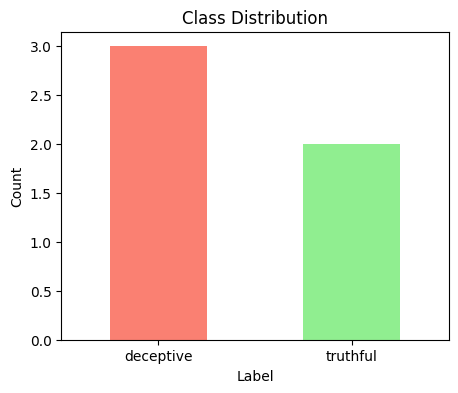

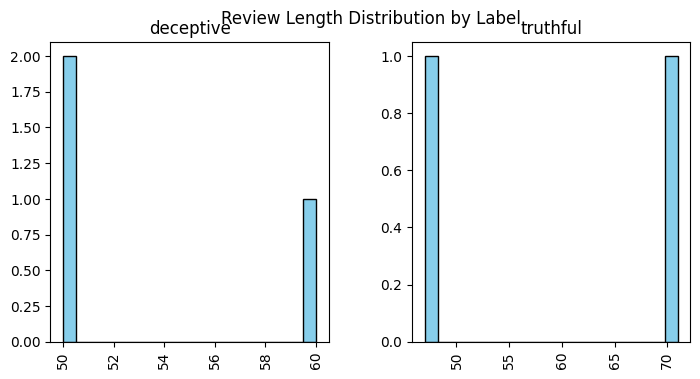

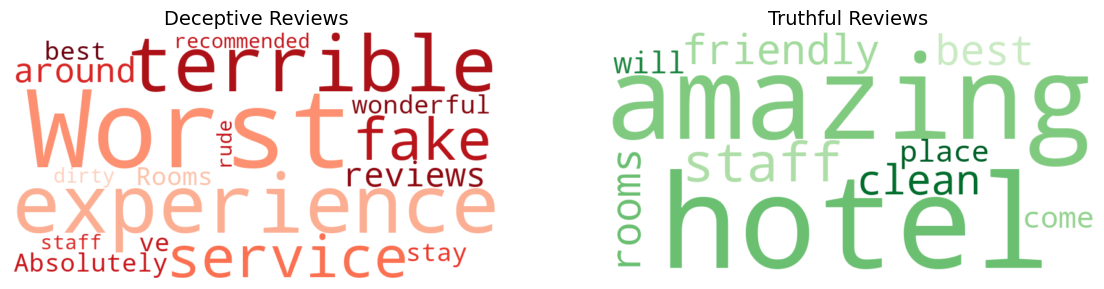

✅ EDA completed successfully!


In [2]:
# ==============================
# ReviewGuard: EDA Notebook
# ==============================

# Step 0: Imports
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import os

# Display plots inline
%matplotlib inline

# Step 1: Load dataset
path = "data/raw/"  # put your unzipped deceptive-opinion-spam corpus here
data = []

for root, _, files in os.walk(path):
    for file in files:
        if file.endswith(".txt"):
            label = "deceptive" if "deceptive" in root.lower() else "truthful"
            with open(os.path.join(root, file), "r", encoding="utf-8") as f:
                data.append((f.read(), label))

if len(data) == 0:
    print("⚠️ No dataset found in data/raw/. Loading mock data for testing.")
    data = [
        ("The hotel was amazing, staff were so friendly and the rooms were clean.", "truthful"),
        ("This is the best place ever, I will come again!", "truthful"),
        ("Worst experience, terrible service, fake reviews all around.", "deceptive"),
        ("Absolutely wonderful stay, the best I’ve ever had!", "deceptive"),
        ("Rooms were dirty, staff was rude, not recommended.", "deceptive"),
    ]

# Create DataFrame
df = pd.DataFrame(data, columns=["review", "label"])
print("✅ Dataset loaded:", df.shape)
display(df.head())

# Step 2: Class distribution
plt.figure(figsize=(5,4))
df['label'].value_counts().plot(
    kind='bar', 
    title='Class Distribution',
    color=['salmon', 'lightgreen'],
    rot=0
)
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# Step 3: Review length analysis
df['length'] = df['review'].apply(len)
df.hist(column='length', by='label', bins=20, figsize=(8,4), color='skyblue', edgecolor='black')
plt.suptitle('Review Length Distribution by Label')
plt.show()

# Step 4: Word Clouds
fake_text = ' '.join(df[df.label=='deceptive'].review)
real_text = ' '.join(df[df.label=='truthful'].review)

wc_fake = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(fake_text)
wc_real = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(real_text)

# Display word clouds
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.imshow(wc_fake, interpolation='bilinear')
plt.title("Deceptive Reviews", fontsize=14)
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(wc_real, interpolation='bilinear')
plt.title("Truthful Reviews", fontsize=14)
plt.axis("off")
plt.show()

print("✅ EDA completed successfully!")
